# **02 - Analysis and Visualizations**

## Objectives
* Analyse the cleaned online retail dataset to answer 4 business requirements 
  through visualisations

## Inputs
* data/processed/online_retail_cleaned.csv

## Outputs
* 4 visualisations answering business requirements

## Additional Comments
* Cleaned data produced in notebook 01_load_and_clean_data.ipynb

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/tildeholmqvist/Documents/VS_Code_Tilde/DA_project_1/DA_project_1/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/tildeholmqvist/Documents/VS_Code_Tilde/DA_project_1/DA_project_1'

## Install Dependencies

This cell installs all required packages listed in `requirements.txt`. 

In [4]:
!pip install -r requirements.txt

# Import Libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.pipeline import Pipeline
from feature_engine import transformation as vt

## Load Cleaned Data

The cleaned dataset produced in notebook 01 is loaded here. 
`dtype={'InvoiceNo': str}` is specified to avoid a `DtypeWarning` 
caused by mixed types when reloading a CSV saved with string identifiers.

* Input: data/processed/online_retail_cleaned.csv

In [6]:
df = pd.read_csv(
    "data/processed/online_retail_cleaned.csv",
    dtype={'InvoiceNo': str}
)
print(df.shape)
df.head()

(524878, 11)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,Year
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,12,2010
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,2010
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,12,2010
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,2010
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,12,2010


## Descriptive Statistics

Basic statistical summary of the cleaned dataset.

In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID,TotalPrice,Month,Year
count,524878.000000,524878.000000,524878.000000,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,15287.631345,20.275399,7.552237,2010.921904
std,156.280031,36.093028,1482.145530,271.693566,3.508164,0.268323
min,1.000000,0.001000,12346.000000,0.001000,1.000000,2010.000000
25%,1.000000,1.250000,14375.000000,3.900000,5.000000,2011.000000
50%,4.000000,2.080000,15287.000000,9.920000,8.000000,2011.000000
75%,11.000000,4.130000,16245.000000,17.700000,11.000000,2011.000000
max,80995.000000,13541.330000,18287.000000,168469.600000,12.000000,2011.000000


The table above provides a basic statistical overview of the dataset. 
Key observations:
- The average unit price is £3.92, suggesting a low-price product range
- The average quantity per transaction is 10.6 units
- The large standard deviation in Quantity (156) indicates some bulk 
  orders exist — these are kept in the dataset as they represent 
  legitimate wholesale purchases

## AI Integration Note — Data Loading

Claude (Anthropic) was asked to review the data loading step in this notebook.

Claude identified a `DtypeWarning` on the `InvoiceNo` column, caused by mixed types when reloading a CSV that was saved with `InvoiceNo` as a string type. To resolve this, `dtype={'InvoiceNo': str}` was added to the `pd.read_csv()` call above.

---

# Business Requirements

## BR1 — Most Popular Products

* Which products are sold the most by quantity?

Hypothesis: A small number of products will account for the majority of total sales 
(Pareto principle — 20% of products generate 80% of sales).

In [79]:
fig = px.bar(
    data_frame=df.groupby("Description")["Quantity"]
        .sum()
        .nlargest(10)
        .sort_values(ascending=True)
        .reset_index(),
    x="Quantity",
    y="Description",
    orientation='h',
    color="Quantity",
    color_continuous_scale="viridis",
    title="Top 10 Best-Selling Products by Quantity",
    labels={
        "Quantity": "Total Quantity Sold",
        "Description": "Product"
    }
)
fig.show()

**Outcome:** The chart shows that "Paper Craft Little Birdie" 
significantly outsells all other products. The top 10 products are 
predominantly home décor and novelty items, suggesting this is the 
retailer's core category. The hypothesis is partially supported,
while top products clearly outsell others, the strict 80/20 Pareto 
rule was not verified quantitatively in this analysis.

---

## BR2 — Sales Trends Over Time

* How have sales developed month by month over the years?

Hypothesis: The fourth quarter (October-December) will show the 
highest sales activity due to the Christmas shopping period.

Monthly revenue and order counts are aggregated by year and month. 
A `YearMonth` string column is created for use as the x-axis label 
in the time series plots below.

In [9]:
monthly_sales = df.groupby(["Year", "Month"]).agg(
    TotalRevenue=("TotalPrice", "sum"),
    TotalOrders=("InvoiceNo", "nunique")
).reset_index()

monthly_sales["YearMonth"] = (
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str).str.zfill(2)
)

print(monthly_sales.head())

   Year  Month  TotalRevenue  TotalOrders YearMonth
0  2010     12    821452.730         1559   2010-12
1  2011      1    689811.610         1086   2011-01
2  2011      2    522545.560         1100   2011-02
3  2011      3    716215.260         1454   2011-03
4  2011      4    536968.491         1246   2011-04


In [64]:
fig = px.line(
    data_frame=monthly_sales,
    x="YearMonth",
    y="TotalRevenue",
    title="Monthly Revenue Over Time",
    labels={
        "YearMonth": "Month",
        "TotalRevenue": "Total Revenue (£)"
    }
)
fig.show()

fig2 = px.bar(
    data_frame=monthly_sales,
    x="YearMonth",
    y="TotalOrders",
    title="Monthly Number of Orders Over Time",
    labels={
        "YearMonth": "Month",
        "TotalOrders": "Number of Orders"
    },
    color="TotalOrders",
    color_continuous_scale="viridis"
)
fig2.show()



**Outcome:** Both charts show a clear upward trend toward the end of 
2011, with a peak in November. This supports the hypothesis that Q4 
sees the highest sales activity due to Christmas shopping. The drop 
in December is likely due to incomplete data for that month rather 
than an actual sales decline.

> Note: Revenue and orders are displayed as two separate interactive 
> charts rather than subplots, as Plotly Express handles each figure 
> independently. This allows the user to zoom and interact with each 
> chart individually.

---

## BR3 — Price vs Quantity Relationship

* Is there a correlation between product price and quantity sold? 
Do cheaper products tend to sell in higher quantities?

Hypothesis: Products with a lower unit price will have a higher quantity sold.

Product-level data is aggregated to calculate the average unit price 
and total quantity sold per product. This enables a product-level 
view of the price-quantity relationship rather than a transaction-level view.

In [11]:
price_quantity = df.groupby("Description").agg(
    AveragePrice=("UnitPrice", "mean"),
    TotalQuantity=("Quantity", "sum")
).reset_index()
print(price_quantity.head())

                      Description  AveragePrice  TotalQuantity
0   4 PURPLE FLOCK DINNER CANDLES      2.450513            142
1   50'S CHRISTMAS GIFT BAG LARGE      1.426589           1915
2               DOLLY GIRL BEAKER      1.506420           2451
3     I LOVE LONDON MINI BACKPACK      4.616667            388
4     I LOVE LONDON MINI RUCKSACK      4.150000              1


In [71]:
fig = px.scatter(
    data_frame=price_quantity,
    x="AveragePrice",
    y="TotalQuantity",
    size="TotalQuantity",
    size_max=40,
    color_continuous_scale="Viridis",
    title="Price vs Quantity Sold for Each Product",
    labels={
        "AveragePrice": "Average Unit Price (£)",
        "TotalQuantity": "Total Quantity Sold"
    }
)
fig.show()

**Outcome:** The scatter plot supports the hypothesis. Products with 
lower unit prices achieve higher sales volumes, with the largest 
bubbles concentrated under £5. As price increases, quantity sold 
decreases — confirming a negative relationship between price and quantity.

---

## AI Integration Note

GitHub Copilot was asked: "How can I make this scatterplot more 
easy to understand?"

Copilot suggested several improvements including adding a trendline, 
using transparency to reduce overplotting, log scaling for skewed data, 
and an interactive Plotly version with colour scaling and size mapping.

Based on these suggestions, the following improvement was implemented:
- An interactive Plotly scatter plot where bubble size represents 
  total quantity sold and colour represents average unit price. 
  Hovering over each bubble shows the product name, average price, 
  and total quantity sold.

In [78]:
fig = px.scatter(
    price_quantity,
    x='AveragePrice',
    y='TotalQuantity',
    size='TotalQuantity',
    size_max=40,
    color='AveragePrice',
    hover_data={
        'Description': True,
        'AveragePrice': ':.2f',
        'TotalQuantity': True
    },
    labels={
        'AveragePrice': 'Average Price (£)',
        'TotalQuantity': 'Total Quantity Sold'
    },
    title='Product Price vs Quantity (improved)',
    range_x=[0, 20],
)

fig



**Outcome (improved version):** The addition of colour scale, bubble 
size and hover data description makes the relationship clearer. 
Hovering over individual bubbles reveals the product name, exact price 
and quantity, enabling deeper exploration without cluttering the chart.

___

## BR4 — Price Distribution and Normalisation

* How is unit price distributed across all products, and can a 
transformation normalise the distribution?

Hypothesis: UnitPrice will be right-skewed (most products are cheap, 
few are very expensive). Yeo-Johnson transformation will normalise 
the distribution towards a bell curve.

A sample of 5,000 rows is used to reduce processing time. 
`random_state=42` ensures the sample is reproducible. 
Only rows with `UnitPrice > 0` are included to exclude 
invalid or erroneous price entries.

In [15]:
df_price = df[["UnitPrice"]].copy()
df_price = df_price[df_price["UnitPrice"] > 0]

df_price.head()

,UnitPrice
0,2.55
1,3.39
2,2.75
3,3.39
4,3.39


The following analysis uses the YeoJohnsonTransformer from the 
feature_engine library, applied here to the UnitPrice column.

*** UnitPrice ***


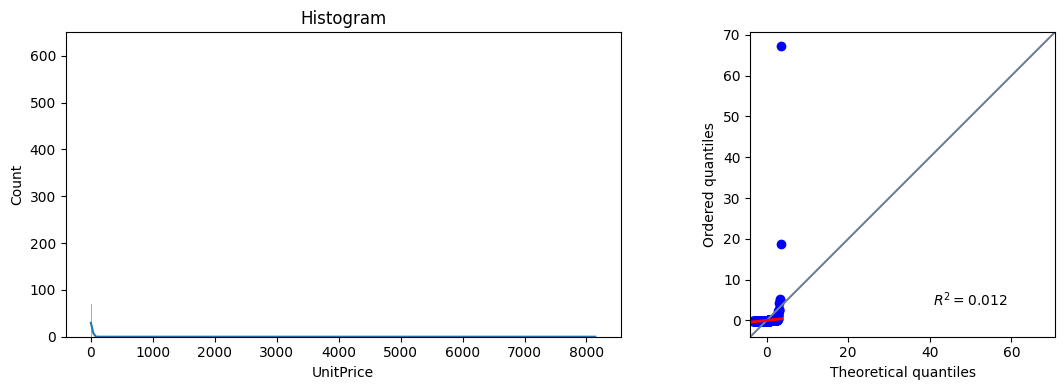

before apply transformation  | skewness: 62.28 | kurtosis: 4119.08




In [16]:
import pingouin as pg


def calculate_skew_kurtosis(df, col, moment):
    print(
        f"{moment}  | skewness: {df[col].skew().round(2)}"
        f" | kurtosis: {df[col].kurtosis().round(2)}"
    )


def distribution_before_applying_transformer(df):
    for col in df.columns:
        print(f"*** {col} ***")
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
        sns.histplot(data=df, x=col, kde=True, ax=axes[0])
        axes[0].set_title("Histogram")
        pg.qqplot(df[col], dist='norm', ax=axes[1])
        plt.tight_layout()
        plt.show()
        calculate_skew_kurtosis(df, col, 'before apply transformation')
        print("\n")


def compare_distributions_before_and_after_applying_transformer(
    df, df_transformed, method
):
    for col in df.columns:
        print(f"*** {col} ***")
        fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
        sns.histplot(data=df, x=col, kde=True, ax=axes[0, 0])
        axes[0, 0].set_title(f'Before {method}')
        pg.qqplot(df[col], dist='norm', ax=axes[0, 1])

        sns.histplot(data=df_transformed, x=col, kde=True, ax=axes[1, 0])
        axes[1, 0].set_title(f'After {method}')
        pg.qqplot(df_transformed[col], dist='norm', ax=axes[1, 1])

        plt.tight_layout()
        plt.show()
        calculate_skew_kurtosis(df, col, moment='before transformation')
        calculate_skew_kurtosis(df_transformed, col, moment='after transformation')
        print("\n")


df_price_sample = df_price.sample(n=5000, random_state=42)
distribution_before_applying_transformer(df_price_sample)

> **Note — How to read this plot:**
>
> Each analysis shows two charts side by side:
> - **Histogram (left):** Shows the distribution of UnitPrice. A bell-shaped curve indicates a normal distribution.
> - **QQ-plot (right):** Compares the data against a perfect normal distribution. If the points follow the diagonal line closely, the data is normally distributed. R² measures how well the data fits the line — a value close to 1.0 means near-perfect normality.

In [ ]:
pipeline = Pipeline([
    ('yeo_johnson', vt.YeoJohnsonTransformer())
])

df_transformed = pipeline.fit_transform(df_price_sample)
df_transformed.head()

,UnitPrice
404269,0.887861
293030,0.769411
206516,0.528676
387547,1.112413
445148,0.764775


*** UnitPrice ***


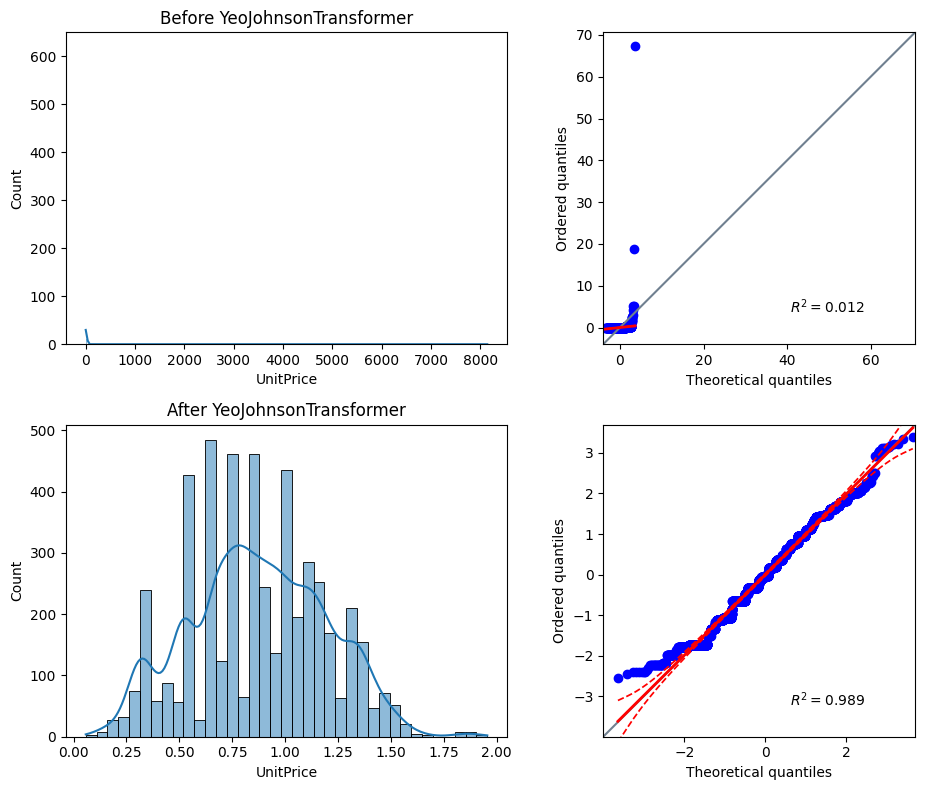

before transformation  | skewness: 62.28 | kurtosis: 4119.08
after transformation  | skewness: 0.05 | kurtosis: -0.46




In [82]:
compare_distributions_before_and_after_applying_transformer(df_price_sample, df_transformed, method='YeoJohnsonTransformer')

**Outcome:**

The Yeo-Johnson transformation successfully normalised the UnitPrice 
distribution. Before transformation, the data was heavily right-skewed 
(R²=0.012), confirming that most products are low-priced with a few 
very expensive outliers. After transformation, the distribution closely 
follows a normal bell curve (R²=0.989), confirming the hypothesis.

____

## Visualisation Alternatives Considered

- **BR1 — Top Products (bar chart):** A pie chart was considered but 
  rejected — it is harder to compare values accurately across many 
  categories than a horizontal bar chart.
- **BR2 — Sales Trends (line + bar chart):** A single combined chart 
  was considered but two separate interactive Plotly charts were used 
  instead, allowing independent zooming and exploration of revenue 
  and order trends.
- **BR3 — Price vs Quantity (scatter plot):** A box plot was considered 
  but rejected, as it does not show the relationship between two 
  continuous variables. A scatter plot with bubble size was chosen to 
  show three dimensions simultaneously.
- **BR4 — Price Distribution:** Log Transformer, Reciprocal Transformer, 
  Power Transformer, Box-Cox and Yeo-Johnson were all tested. 
  Yeo-Johnson produced the best fit (R²=0.989) and is preferred 
  as it is more generalizable.